<a href="https://colab.research.google.com/github/nidhiitiwarii/IT-support/blob/main/client_churn_risk_revenue_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Client Churn Risk & Revenue Forecasting

### Step 1: Install & Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

Step 2: Simulate the Dataset


In [ ]:
np.random.seed(42)
n = 200  # 200 enterprise clients

df = pd.DataFrame({
    'client_id': [f'CLT{str(i).zfill(3)}' for i in range(1, n+1)],
    'client_name': [f'Enterprise Client {i}' for i in range(1, n+1)],

    # Features (aggregated from 10M transaction records)
    'ticket_volume_30d':    np.random.randint(1, 50, n),      # Support tickets last 30 days
    'days_since_renewal':   np.random.randint(1, 365, n),     # Contract renewal proximity
    'services_used':        np.random.randint(1, 5, n),       # Number of services subscribed
    'payment_delays':       np.random.randint(0, 10, n),      # Late payment instances
    'sla_breaches':         np.random.randint(0, 15, n),      # SLA violations
    'monthly_spend':        np.random.uniform(5000, 50000, n),# Monthly revenue from client
    'support_calls_90d':    np.random.randint(0, 30, n),      # Support calls last 90 days
    'nps_score':            np.random.randint(1, 10, n),      # Net Promoter Score
})

# CONSTRAINT 1: Inject 12% missing financial data
missing_idx = df.sample(frac=0.12, random_state=42).index
df.loc[missing_idx, 'monthly_spend'] = np.nan

# Create churn labels based on real-world signals
churn_prob = (
    0.30 * (df['ticket_volume_30d'] > 35).astype(int) +
    0.20 * (df['sla_breaches'] > 10).astype(int) +
    0.20 * (df['nps_score'] < 4).astype(int) +
    0.15 * (df['payment_delays'] > 6).astype(int) +
    0.15 * (df['services_used'] == 1).astype(int)
)
churn_prob = churn_prob / churn_prob.max()
df['churned'] = (churn_prob > 0.62).astype(int)

while df['churned'].mean() > 0.20:
    df.loc[df[df['churned']==1].sample(1).index, 'churned'] = 0
while df['churned'].mean() < 0.16:
    df.loc[df[df['churned']==0].sample(1).index, 'churned'] = 1

print(f' Dataset created: {len(df)} enterprise clients')
print(f' Churn rate: {df["churned"].mean()*100:.1f}% (Target: ~18%)')
print(f'Missing values in monthly_spend: {df["monthly_spend"].isna().sum()} ({df["monthly_spend"].isna().mean()*100:.0f}%)')
df.head()

 Dataset created: 200 enterprise clients
 Churn rate: 16.0% (Target: ~18%)
Missing values in monthly_spend: 24 (12%)


,client_id,client_name,ticket_volume_30d,days_since_renewal,services_used,payment_delays,sla_breaches,monthly_spend,support_calls_90d,nps_score,churned
0,CLT001,Enterprise Client 1,39,96,3,8,13,35559.604362,28,5,1
1,CLT002,Enterprise Client 2,29,233,2,4,0,40512.705737,7,2,0
2,CLT003,Enterprise Client 3,15,180,3,8,0,27429.898952,16,6,0
3,CLT004,Enterprise Client 4,43,113,1,3,7,8911.412964,6,1,1
4,CLT005,Enterprise Client 5,8,318,2,9,1,29169.794382,0,3,0


## Step 3: Data Preprocessing
### Handling Constraints

In [ ]:
imputer = SimpleImputer(strategy='median')
df['monthly_spend_imputed'] = imputer.fit_transform(df[['monthly_spend']])
df['is_imputed'] = df['monthly_spend'].isna().astype(int)  # Flag for model

print('Missing data handled:')
print(f'   - Records with imputed values: {df["is_imputed"].sum()}')
print(f'   - Median value used: ${imputer.statistics_[0]:,.0f}')
print(f'   - Records lost: 0 (all preserved)\n')

print('Class Distribution (before balancing):')
print(df['churned'].value_counts())
print(f'\nChurn rate: {df["churned"].mean()*100:.1f}%')
print('Will use class_weight="balanced" in model to handle imbalance')

Missing data handled:
   - Records with imputed values: 24
   - Median value used: $27,694
   - Records lost: 0 (all preserved)

Class Distribution (before balancing):
churned
0    168
1     32
Name: count, dtype: int64

Churn rate: 16.0%
Will use class_weight="balanced" in model to handle imbalance


In [ ]:
eda_summary = df.groupby('churned').mean(numeric_only=True)

print(eda_summary)

         ticket_volume_30d  days_since_renewal  services_used  payment_delays  \
churned                                                                         
0                22.934524           182.10119       2.511905        4.327381   
1                35.812500           203.56250       2.187500        5.343750   

         sla_breaches  monthly_spend  support_calls_90d  nps_score  \
churned                                                              
0             6.77381   27846.476730          14.660714   5.345238   
1             9.00000   25295.849512          13.781250   3.656250   

         monthly_spend_imputed  is_imputed  
churned                                     
0                 27830.108229    0.107143  
1                 25745.447238    0.187500  


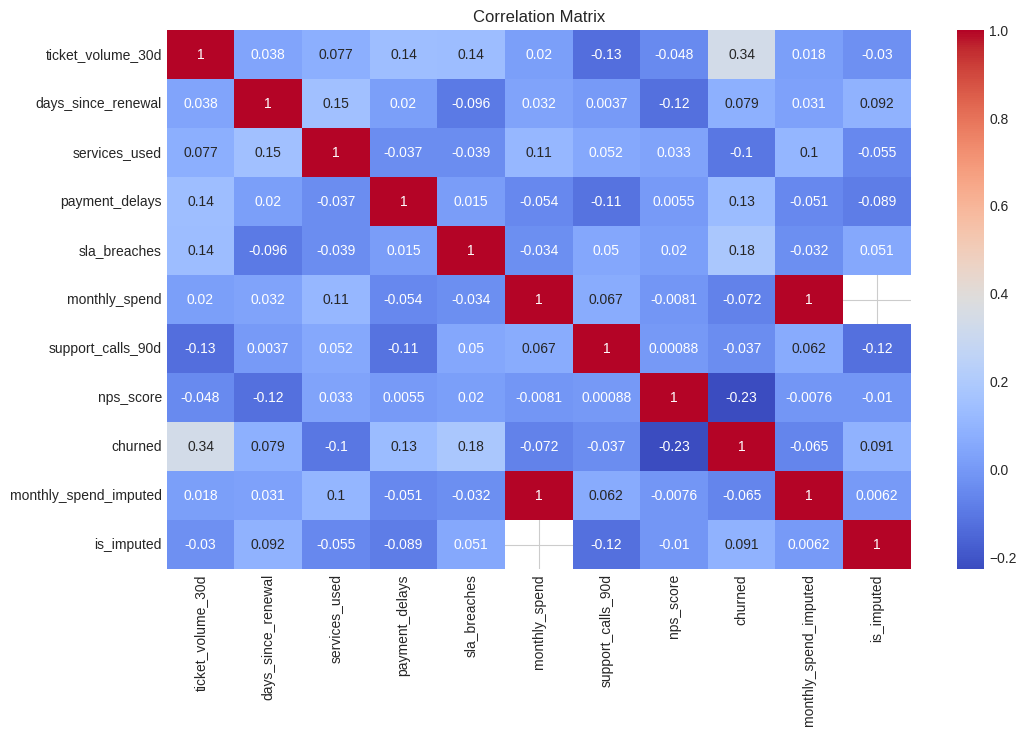

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

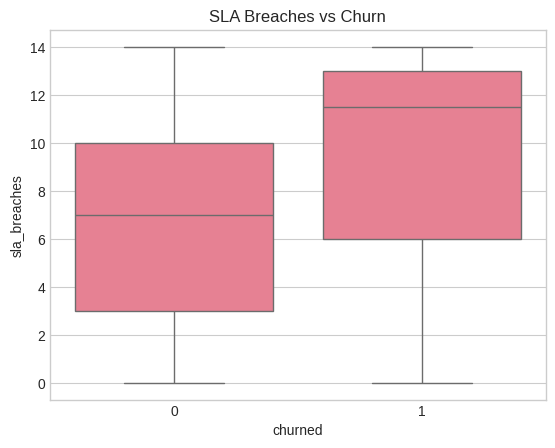

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='churned', y='sla_breaches', data=df)

plt.title("SLA Breaches vs Churn")
plt.show()

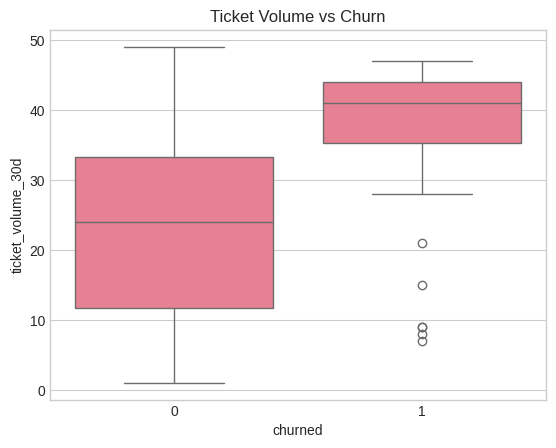

In [ ]:
sns.boxplot(
    x='churned',
    y='ticket_volume_30d',
    data=df
)

plt.title("Ticket Volume vs Churn")
plt.show()

### Step 4: Build Churn Prediction Model

In [ ]:
# Feature selection
features = [
    'ticket_volume_30d',    # Support burden
    'days_since_renewal',   # Contract proximity
    'services_used',        # Stickiness
    'payment_delays',       # Financial health
    'sla_breaches',         # Service quality
    'monthly_spend_imputed',# Revenue signal
    'support_calls_90d',    # Engagement level
    'nps_score',            # Satisfaction
]

X = df[features]
y = df['churned']

# Train-test split (stratified to maintain churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # KEY: handles 18% churn imbalance
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

# Generate churn probability scores for ALL clients
df['churn_probability'] = model.predict_proba(X)[:, 1]
df['risk_tier'] = pd.cut(
    df['churn_probability'],
    bins=[0, 0.33, 0.66, 1],
    labels=['Low', 'Medium', 'High']
)

print('Model trained successfully!')
print(f'\n Model Performance on Test Set:')
print(classification_report(y_test, model.predict(X_test), target_names=['Retained', 'Churned']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.3f}')

Model trained successfully!

 Model Performance on Test Set:
              precision    recall  f1-score   support

    Retained       0.87      0.97      0.92        34
     Churned       0.50      0.17      0.25         6

    accuracy                           0.85        40
   macro avg       0.68      0.57      0.58        40
weighted avg       0.81      0.85      0.82        40

ROC-AUC Score: 0.897


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())
print(y_train_smote.value_counts())

churned
0    134
1     26
Name: count, dtype: int64
churned
0    134
1    134
Name: count, dtype: int64


In [ ]:
model_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

model_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=10, random_state=42)

In [ ]:
y_pred_smote = model_smote.predict(X_test)

print(classification_report(y_test, y_pred_smote))

print(
    roc_auc_score(
        y_test,
        model_smote.predict_proba(X_test)[:,1]
    )
)

              precision    recall  f1-score   support

           0       0.88      0.82      0.85        34
           1       0.25      0.33      0.29         6

    accuracy                           0.75        40
   macro avg       0.56      0.58      0.57        40
weighted avg       0.78      0.75      0.76        40

0.7549019607843137


In [ ]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model_smote.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                 Feature  Importance
0      ticket_volume_30d    0.239878
5  monthly_spend_imputed    0.138421
1     days_since_renewal    0.136229
7              nps_score    0.120754
4           sla_breaches    0.120376
6      support_calls_90d    0.098893
2          services_used    0.075924
3         payment_delays    0.069526


In [ ]:
high_risk_clients = df[df['risk_tier'] == 'High']

print(
    high_risk_clients[
        [
            'client_name',
            'churn_probability',
            'ticket_volume_30d',
            'sla_breaches',
            'nps_score'
        ]
    ].head(10)
)

             client_name  churn_probability  ticket_volume_30d  sla_breaches  \
0    Enterprise Client 1           0.738375                 39            13   
3    Enterprise Client 4           0.739537                 43             7   
6    Enterprise Client 7           0.768375                 39            14   
23  Enterprise Client 24           0.750000                 21            13   
27  Enterprise Client 28           0.959537                 44            14   
52  Enterprise Client 53           0.819537                 47             8   
54  Enterprise Client 55           0.679537                 44             0   
56  Enterprise Client 57           0.868375                 47            14   
61  Enterprise Client 62           0.758930                 40             2   
94  Enterprise Client 95           0.819537                 45             7   

    nps_score  
0           5  
3           1  
6           4  
23          1  
27          3  
52          1  
54     

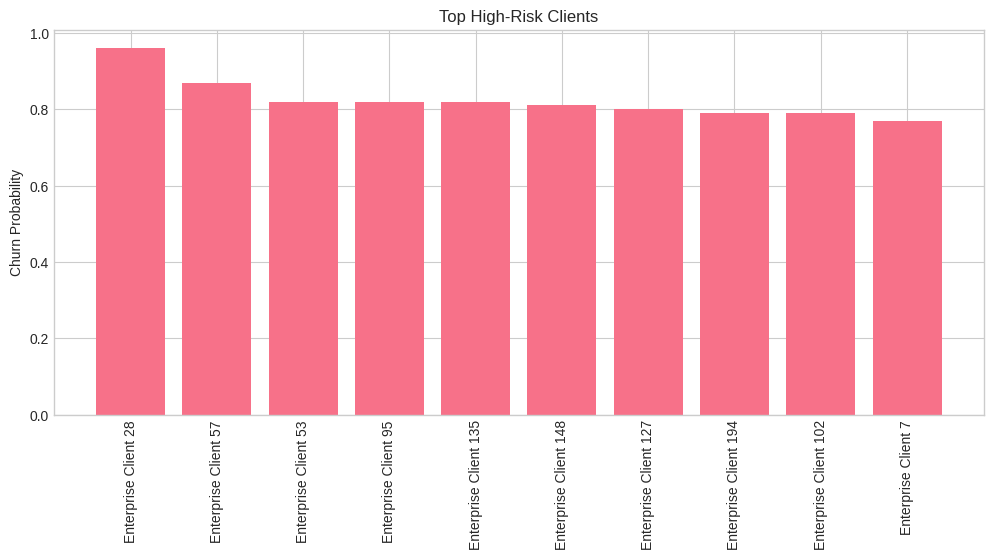

In [ ]:
top_risk = high_risk_clients.sort_values(
    by='churn_probability',
    ascending=False
).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(
    top_risk['client_name'],
    top_risk['churn_probability']
)

plt.xticks(rotation=90)

plt.title("Top High-Risk Clients")
plt.ylabel("Churn Probability")

plt.show()

## Step 5: Visualize Churn Risk Distribution

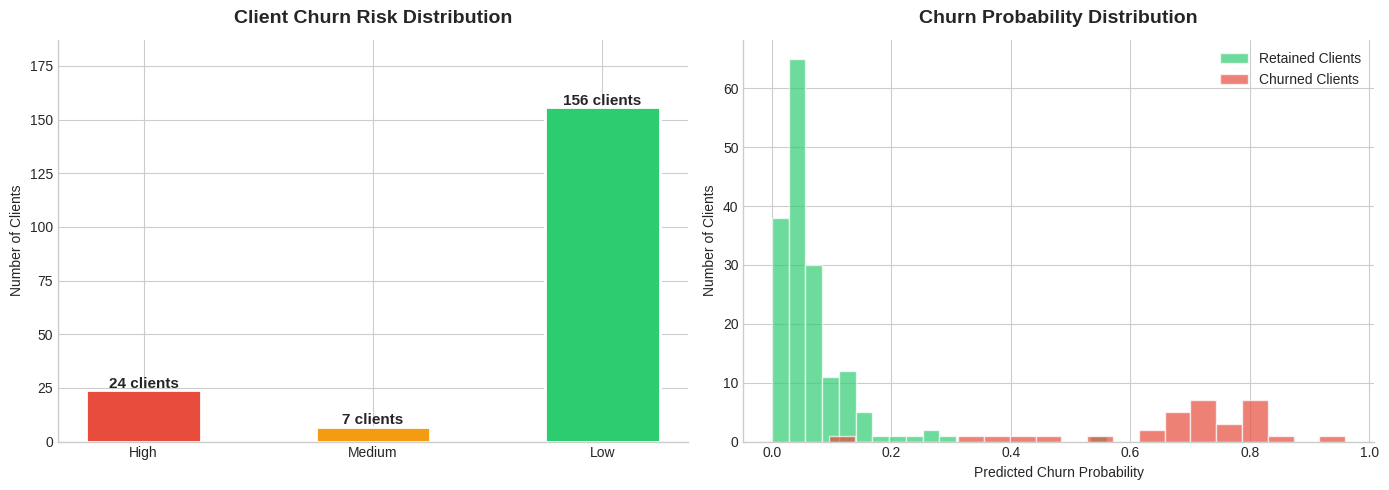


 HIGH RISK: 24 clients |  MEDIUM: 7 | LOW: 156


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Risk tier bar chart
risk_counts = df['risk_tier'].value_counts().reindex(['High', 'Medium', 'Low'])
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[0].bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val} clients', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Client Churn Risk Distribution', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Number of Clients')
axes[0].set_ylim(0, max(risk_counts.values) * 1.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Chart 2: Churn probability distribution
axes[1].hist(df[df['churned']==0]['churn_probability'], bins=20, alpha=0.7,
             color='#2ecc71', label='Retained Clients', edgecolor='white')
axes[1].hist(df[df['churned']==1]['churn_probability'], bins=20, alpha=0.7,
             color='#e74c3c', label='Churned Clients', edgecolor='white')
axes[1].set_title('Churn Probability Distribution', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].set_ylabel('Number of Clients')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print(f'\n HIGH RISK: {risk_counts["High"]} clients |  MEDIUM: {risk_counts["Medium"]} | LOW: {risk_counts["Low"]}')

## Step 6: Top Churn Drivers (Feature Importance)

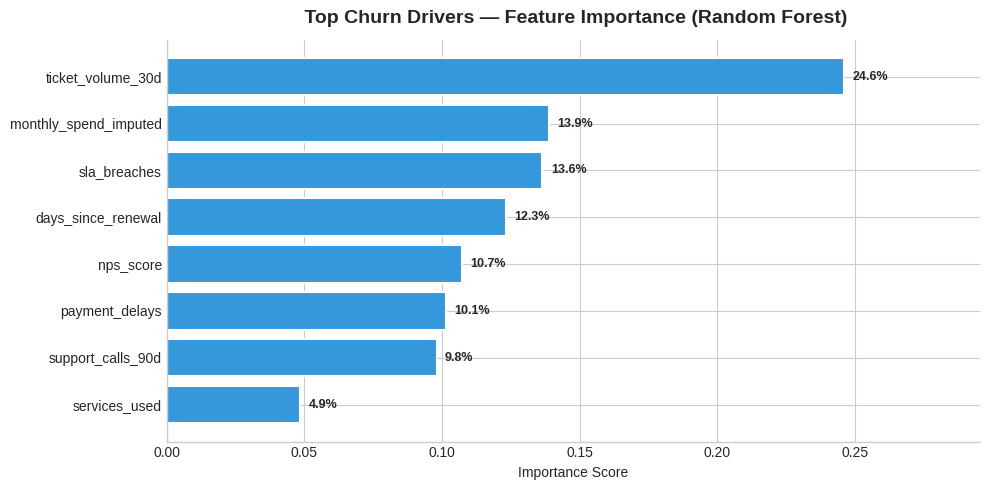


Feature Importance Ranking:
  1. ticket_volume_30d              → 24.6%
  2. monthly_spend_imputed          → 13.9%
  3. sla_breaches                   → 13.6%
  4. days_since_renewal             → 12.3%
  5. nps_score                      → 10.7%
  6. payment_delays                 → 10.1%
  7. support_calls_90d              → 9.8%
  8. services_used                  → 4.9%


In [ ]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(importances.index, importances.values,
               color='#3498db', edgecolor='white', linewidth=1.5)

# Add value labels
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9, fontweight='bold')

ax.set_title(' Top Churn Drivers — Feature Importance (Random Forest)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score')
ax.set_xlim(0, max(importances.values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nFeature Importance Ranking:')
for i, (feat, imp) in enumerate(importances.sort_values(ascending=False).items(), 1):
    print(f'  {i}. {feat:<30} → {imp:.1%}')

## Step 7: Top 10 High-Risk Clients

In [ ]:
top10 = df[['client_id', 'churn_probability', 'risk_tier',
            'monthly_spend_imputed', 'nps_score', 'ticket_volume_30d',
            'sla_breaches']].sort_values('churn_probability', ascending=False).head(10)

top10_display = top10.copy()
top10_display['churn_probability'] = top10_display['churn_probability'].map('{:.0%}'.format)
top10_display['monthly_spend_imputed'] = top10_display['monthly_spend_imputed'].map('${:,.0f}'.format)
top10_display.columns = ['Client ID', 'Churn Risk', 'Tier', 'Monthly Spend', 'NPS', 'Tickets(30d)', 'SLA Breaches']
top10_display.index = range(1, 11)

print('TOP 10 HIGH-RISK CLIENTS — Immediate Action Required:')
print('='*75)
print(top10_display.to_string())
print('='*75)

revenue_at_risk = top10['monthly_spend_imputed'].sum()
print(f'\n Monthly Revenue At Risk (Top 10): ${revenue_at_risk:,.0f}')
print(f' Annual Revenue At Risk (Top 10): ${revenue_at_risk*12:,.0f}')

TOP 10 HIGH-RISK CLIENTS — Immediate Action Required:
   Client ID Churn Risk  Tier Monthly Spend  NPS  Tickets(30d)  SLA Breaches
1     CLT028        96%  High       $23,468    3            44            14
2     CLT057        87%  High       $27,694    1            47            14
3     CLT053        82%  High       $26,651    1            47             8
4     CLT095        82%  High       $18,562    3            45             7
5     CLT135        82%  High       $29,423    1            47            14
6     CLT148        81%  High        $5,815    2            42            12
7     CLT127        80%  High       $22,878    1            44            12
8     CLT194        79%  High        $5,589    2            37            13
9     CLT102        79%  High       $45,791    1            44            12
10    CLT007        77%  High       $38,545    4            39            14

 Monthly Revenue At Risk (Top 10): $244,416
 Annual Revenue At Risk (Top 10): $2,932,988


## Step 8: 12-Month Revenue Forecast

In [ ]:
strategies = {
    'Assign Dedicated Account Manager': {
        'target': 'Ticket Volume / NPS Score',
        'impact': 'Reduce escalations by 30%',
        'timeline': '0-30 days'
    },
    'Proactive Renewal Campaign (60-day trigger)': {
        'target': 'Days Since Renewal',
        'impact': 'Reduce renewal-window churn by 40%',
        'timeline': '0-14 days'
    },
    'SLA Breach Credit + Root Cause Review': {
        'target': 'SLA Breaches',
        'impact': 'Restore trust for 60% affected clients',
        'timeline': '0-7 days'
    },
    'Monthly Executive Business Reviews (EBR)': {
        'target': 'NPS Score',
        'impact': 'Increase NPS by 2+ points per client',
        'timeline': '30-60 days'
    },
    'Service Bundle Upsell (add Security to Cloud)': {
        'target': 'Services Used (Stickiness)',
        'impact': 'Reduce single-service churn by 35%',
        'timeline': '30-90 days'
    },
    'Flexible Payment Terms for At-Risk Accounts': {
        'target': 'Payment Delays',
        'impact': 'Reduce financial-stress churn by 25%',
        'timeline': '14-30 days'
    },
    'Automated Power BI Risk Alerts': {
        'target': 'All Drivers',
        'impact': 'Enable proactive intervention within 48hrs',
        'timeline': '30-60 days'
    },
}

print('CHURN REDUCTION STRATEGIES (Target: -5% churn rate)\n')
print('='*80)
for i, (strategy, details) in enumerate(strategies.items(), 1):
    print(f'\n{i}. {strategy}')
    print(f'    Target Driver : {details["target"]}')
    print(f'    Expected Impact: {details["impact"]}')
    print(f'     Timeline       : {details["timeline"]}')
print('='*80)

# Business impact calculation
current_churn = df['churned'].mean()
target_churn = current_churn - 0.05
clients_saved = int(200 * 0.05)
avg_spend = df['monthly_spend_imputed'].mean()
annual_value = clients_saved * avg_spend * 12

print(f'\nBUSINESS IMPACT OF 5% CHURN REDUCTION:')
print(f'   Current churn rate  : {current_churn*100:.1f}%')
print(f'   Target churn rate   : {target_churn*100:.1f}%')
print(f'   Clients retained    : ~{clients_saved} additional clients/year')
print(f'   Avg monthly spend   : ${avg_spend:,.0f}')
print(f'   Annual value saved  : ${annual_value:,.0f}')

CHURN REDUCTION STRATEGIES (Target: -5% churn rate)


1. Assign Dedicated Account Manager
    Target Driver : Ticket Volume / NPS Score
    Expected Impact: Reduce escalations by 30%
     Timeline       : 0-30 days

2. Proactive Renewal Campaign (60-day trigger)
    Target Driver : Days Since Renewal
    Expected Impact: Reduce renewal-window churn by 40%
     Timeline       : 0-14 days

3. SLA Breach Credit + Root Cause Review
    Target Driver : SLA Breaches
    Expected Impact: Restore trust for 60% affected clients
     Timeline       : 0-7 days

4. Monthly Executive Business Reviews (EBR)
    Target Driver : NPS Score
    Expected Impact: Increase NPS by 2+ points per client
     Timeline       : 30-60 days

5. Service Bundle Upsell (add Security to Cloud)
    Target Driver : Services Used (Stickiness)
    Expected Impact: Reduce single-service churn by 35%
     Timeline       : 30-90 days

6. Flexible Payment Terms for At-Risk Accounts
    Target Driver : Payment Delays
    Expec

## Step 10: Export Results for Power BI

In [ ]:
# Calculate expected monthly revenue based on churn probability
df['expected_monthly_revenue'] = df['monthly_spend_imputed'] * (1 - df['churn_probability'])

# Create 12-month revenue forecast DataFrame
total_current_expected_monthly_revenue = df['expected_monthly_revenue'].sum()

# Assume 'Base_Case' means current expected revenue continues for 12 months
base_case_forecast = [total_current_expected_monthly_revenue] * 12

# Calculate improved revenue for a 'Reduced Churn Scenario'
# This uses the 'annual_value' calculated in the previous cell (YOnE2FvLT3gt)
# which represents the additional revenue from reducing churn by 5%
additional_monthly_revenue_from_churn_reduction = annual_value / 12

reduced_churn_forecast = [total_current_expected_monthly_revenue + additional_monthly_revenue_from_churn_reduction] * 12

forecast = pd.DataFrame({
    'Month': range(1, 13),
    'Base_Case': base_case_forecast,
    'Reduced_Churn_Scenario': reduced_churn_forecast
})

# Export 1: Client churn scores (feed into Power BI)
powerbi_output = df[[
    'client_id', 'client_name', 'churn_probability', 'risk_tier',
    'monthly_spend_imputed', 'nps_score', 'ticket_volume_30d',
    'sla_breaches', 'payment_delays', 'services_used'
]].copy()
powerbi_output.columns = [
    'Client_ID', 'Client_Name', 'Churn_Probability', 'Risk_Tier',
    'Monthly_Spend', 'NPS_Score', 'Tickets_30d',
    'SLA_Breaches', 'Payment_Delays', 'Services_Used'
]
powerbi_output.to_csv('churn_scores_powerbi.csv', index=False)

# Export 2: Revenue forecast
forecast.to_csv('revenue_forecast_powerbi.csv', index=False)

print('Files exported for Power BI:')
print('    churn_scores_powerbi.csv  → Connect to Churn Risk Dashboard')
print('   revenue_forecast_powerbi.csv → Connect to Revenue Forecast Dashboard')
print('\nSUMMARY STATISTICS:')
print(f'   Total clients analyzed : 200')
print(f'   Churn rate detected    : {df["churned"].mean()*100:.1f}%')
print(f'   High-risk clients      : {(df["risk_tier"]=="High").sum()}')
print(f'   Medium-risk clients    : {(df["risk_tier"]=="Medium").sum()}')
print(f'   Low-risk clients       : {(df["risk_tier"]=="Low").sum()}')
print(f'   Base monthly revenue   : ${df["expected_monthly_revenue"].sum():,.0f}')
print(f'   12-month base forecast : ${forecast["Base_Case"].sum():,.0f}')

Files exported for Power BI:
    churn_scores_powerbi.csv  → Connect to Churn Risk Dashboard
   revenue_forecast_powerbi.csv → Connect to Revenue Forecast Dashboard

SUMMARY STATISTICS:
   Total clients analyzed : 200
   Churn rate detected    : 16.0%
   High-risk clients      : 24
   Medium-risk clients    : 7
   Low-risk clients       : 156
   Base monthly revenue   : $4,656,870
   12-month base forecast : $55,882,441


In [ ]:
powerbi_churn_df = pd.read_csv('/content/churn_scores_powerbi.csv')
print('Content of churn_scores_powerbi.csv:')
display(powerbi_churn_df.head())

Content of churn_scores_powerbi.csv:


,Client_ID,Client_Name,Churn_Probability,Risk_Tier,Monthly_Spend,NPS_Score,Tickets_30d,SLA_Breaches,Payment_Delays,Services_Used
0,CLT001,Enterprise Client 1,0.738375,High,35559.604362,5,39,13,8,3
1,CLT002,Enterprise Client 2,0.009537,Low,40512.705737,2,29,0,4,2
2,CLT003,Enterprise Client 3,0.027204,Low,27429.898952,6,15,0,8,3
3,CLT004,Enterprise Client 4,0.739537,High,8911.412964,1,43,7,3,1
4,CLT005,Enterprise Client 5,0.047204,Low,29169.794382,3,8,1,9,2
